# Final Behavioral Analysis Report
*Comprehensive Narrative: Voter Mobilization to Micro-Level Behavior*

### Executive Summary
This report analyzes the behavioral patterns of the 2023 Thai General Election, focusing on voter engagement, competitiveness, and regional dynamics. We focus on constituencies with at least 80% reported counts to ensure high-fidelity insights.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.family'] = 'Tahoma'
BEHAVIOR_COLORS = ['#4C78A8', '#72B7B2', '#F58518']
NONPARTY_SINGLE = '#4C78A8'
REFERENCE_LINE = '#E45756'
HEATMAP_CMAP = 'Blues'

base_path = r'd:\election69_analysis\election69'
flat_path = r'd:\election69_analysis\election69_flattened'

with open(os.path.join(base_path, 'info_province.json'), 'r', encoding='utf-8-sig') as f:
    prov_raw = json.load(f)
df_prov_codes = pd.DataFrame(prov_raw['province'])[['prov_id', 'eng']]
df_prov_codes['prov_id'] = df_prov_codes['prov_id'].astype(str).str.strip()

df_regions = pd.read_csv(os.path.join(flat_path, 'thailand_regions_mapping.csv'))
df_regions['prov_id'] = df_regions['prov_id'].astype(str).str.strip()

df_prov_full = df_prov_codes.merge(df_regions[['prov_id', 'province', 'region']], on='prov_id', how='left')
df_prov_full = df_prov_full.rename(columns={'eng': 'province_code'})

df_constituencies = pd.read_csv(os.path.join(flat_path, 'info_constituency.csv'))
df_constituencies['prov_id'] = df_constituencies['prov_id'].astype(str).str.strip()
df_constituencies['cons_id'] = df_constituencies['cons_id'].astype(str).str.strip()

with open(os.path.join(base_path, 'info_party_overview.json'), 'r', encoding='utf-8-sig') as f:
    party_raw = json.load(f)
df_party_info = pd.DataFrame(party_raw)
df_party_info['id'] = pd.to_numeric(df_party_info['id'], errors='coerce')

df_stats_cons_summary = pd.read_csv(os.path.join(flat_path, 'stats_cons_summary.csv'))
df_stats_cons_cand = pd.read_csv(os.path.join(flat_path, 'stats_cons_candidates.csv'))
df_stats_cons_party = pd.read_csv(os.path.join(flat_path, 'stats_cons_party_votes.csv'))

df_stats_cons_cand['party_id'] = pd.to_numeric(df_stats_cons_cand['party_id'], errors='coerce')
df_stats_cons_party['party_id'] = pd.to_numeric(df_stats_cons_party['party_id'], errors='coerce')
df_stats_cons_cand['mp_app_rank'] = pd.to_numeric(df_stats_cons_cand['mp_app_rank'], errors='coerce')

df_stats_cons_summary['cons_id'] = df_stats_cons_summary['cons_id'].astype(str).str.strip()
df_stats_cons_cand['cons_id'] = df_stats_cons_cand['cons_id'].astype(str).str.strip()
df_stats_cons_party['cons_id'] = df_stats_cons_party['cons_id'].astype(str).str.strip()

df_stats_cons_summary = df_stats_cons_summary.merge(df_constituencies[['cons_id', 'prov_id']], on='cons_id', how='left')

df_stats_cons_summary = df_stats_cons_summary[df_stats_cons_summary['percent_count'] >= 80]
active_cons = df_stats_cons_summary['cons_id'].unique()

df_stats_cons_cand = df_stats_cons_cand[df_stats_cons_cand['cons_id'].isin(active_cons)]
df_stats_cons_party = df_stats_cons_party[df_stats_cons_party['cons_id'].isin(active_cons)]

rank_1 = df_stats_cons_cand[df_stats_cons_cand['mp_app_rank'] == 1].copy()
rank_2 = df_stats_cons_cand[df_stats_cons_cand['mp_app_rank'] == 2].copy()

margin_data = rank_1.merge(rank_2[['cons_id', 'mp_app_vote_percent']], on='cons_id', suffixes=('_1', '_2'))
margin_data['vote_share_margin_percent'] = margin_data['mp_app_vote_percent_1'] - margin_data['mp_app_vote_percent_2']

margin_data = margin_data.merge(df_stats_cons_summary[['cons_id', 'percent_turn_out', 'prov_id']], on='cons_id')
margin_data = margin_data.merge(df_party_info[['id', 'name', 'color']], left_on='party_id', right_on='id')
margin_data = margin_data.rename(columns={'name': 'winner_party', 'color': 'winner_color'})

margin_data = margin_data.merge(df_prov_full[['prov_id', 'province', 'province_code', 'region']], on='prov_id')

split_ticket_df = df_stats_cons_cand.merge(
    df_stats_cons_party[['cons_id', 'party_id', 'party_list_vote']],
    on=['cons_id', 'party_id'],
    how='inner'
)
split_ticket_df = split_ticket_df.merge(df_party_info[['id', 'name', 'color']], left_on='party_id', right_on='id')
split_ticket_df = split_ticket_df.rename(columns={'name': 'party_name'})

winner_split_df = rank_1.merge(
    df_stats_cons_party[['cons_id', 'party_id', 'party_list_vote']],
    on=['cons_id', 'party_id'],
    how='inner'
)
winner_split_df = winner_split_df.merge(df_party_info[['id', 'name', 'color']], left_on='party_id', right_on='id')
winner_split_df = winner_split_df.rename(columns={'name': 'party_name'})

party_colors = margin_data.set_index('winner_party')['winner_color'].to_dict()

print(f"Setup Complete. Square figures enforced for synchronized plots.")


Setup Complete. Square figures enforced for synchronized plots.


C:\Users\nuttn\AppData\Local\Temp\ipykernel_73992\1364926362.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='party_name', y='gap', palette=party_colors, showfliers=False, ax=axes[1])


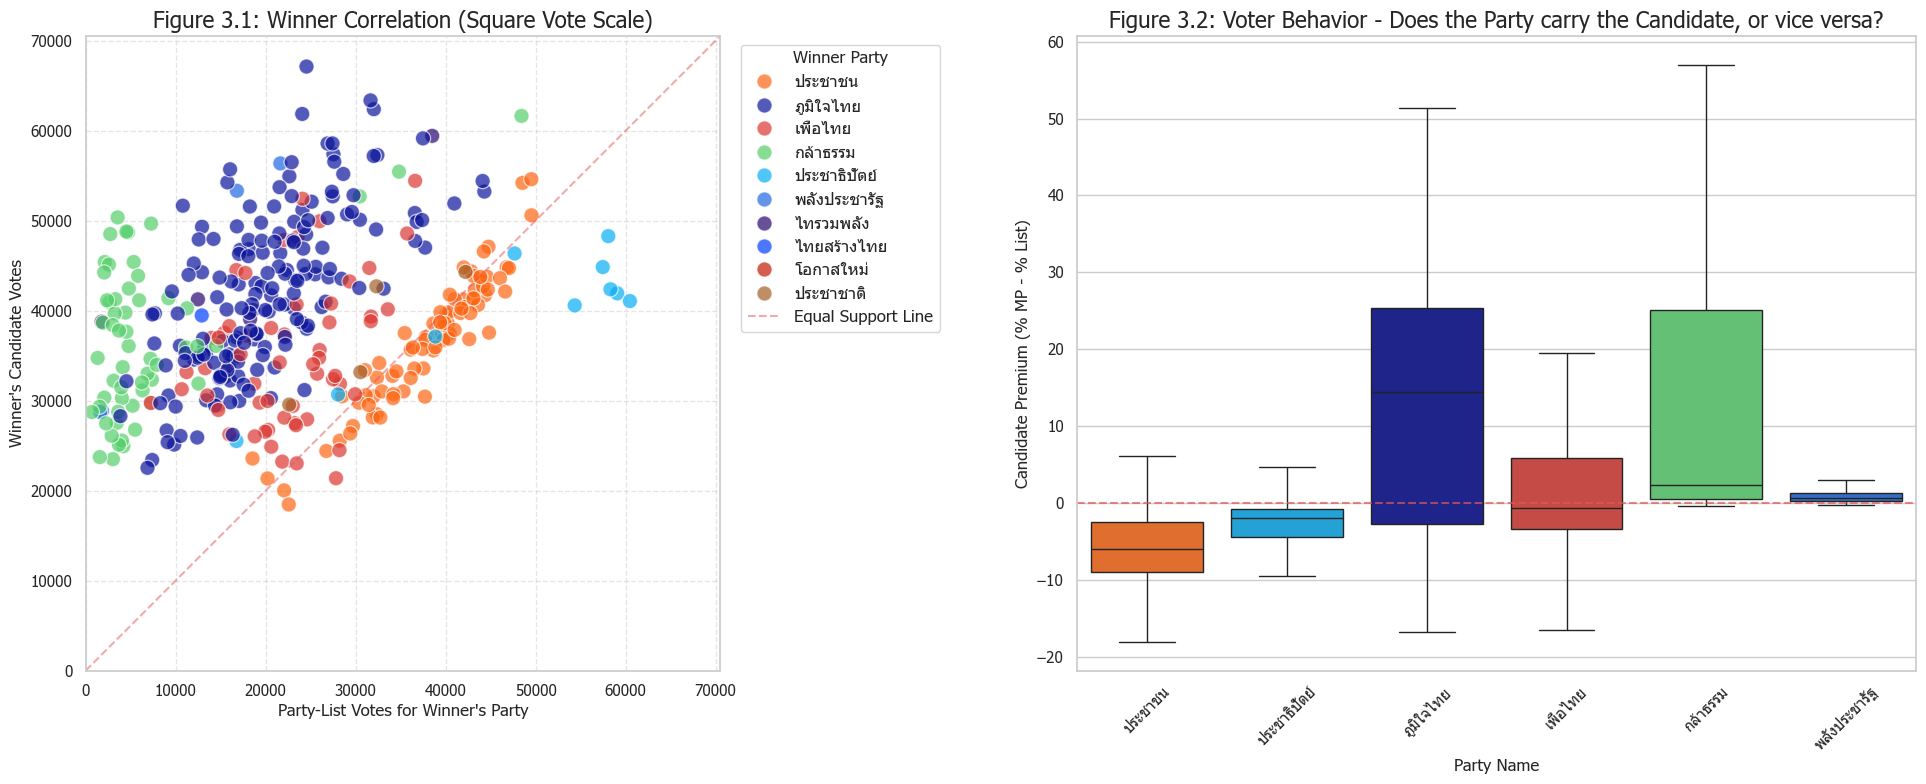

In [39]:

all_candidates_df = split_ticket_df.copy()
all_candidates_df = all_candidates_df.merge(df_stats_cons_summary[['cons_id', 'party_list_valid_votes', 'prov_id']], on='cons_id', how='left')
all_candidates_df['party_list_vote_percent'] = (all_candidates_df['party_list_vote'] / all_candidates_df['party_list_valid_votes'] * 100).fillna(0)
all_candidates_df['gap'] = all_candidates_df['mp_app_vote_percent'] - all_candidates_df['party_list_vote_percent']
top_parties = all_candidates_df.groupby('party_name')['mp_app_vote'].sum().nlargest(6).index
plot_df = all_candidates_df[all_candidates_df['party_name'].isin(top_parties)]

max_votes_win = max(winner_split_df['party_list_vote'].max(), winner_split_df['mp_app_vote'].max()) * 1.05
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.scatterplot(data=winner_split_df, x='party_list_vote', y='mp_app_vote', hue='party_name', palette=party_colors, s=120, alpha=0.7, edgecolor='w', ax=axes[0])
axes[0].set_xlim(0, max_votes_win)
axes[0].set_ylim(0, max_votes_win)
axes[0].set_aspect('equal', adjustable='box')
axes[0].plot([0, max_votes_win], [0, max_votes_win], linestyle='--', color=REFERENCE_LINE, alpha=0.5, label='Equal Support Line')
axes[0].set_title('Figure 3.1: Winner Correlation (Square Vote Scale)', fontsize=16)
axes[0].set_xlabel('Party-List Votes for Winner\'s Party')
axes[0].set_ylabel('Winner\'s Candidate Votes')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(title='Winner Party', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12)

sns.boxplot(data=plot_df, x='party_name', y='gap', palette=party_colors, showfliers=False, ax=axes[1])
axes[1].axhline(0, color=REFERENCE_LINE, linestyle='--', alpha=0.7)
axes[1].set_title('Figure 3.2: Voter Behavior - Does the Party carry the Candidate, or vice versa?', fontsize=16)
axes[1].set_ylabel('Candidate Premium (% MP - % List)')
axes[1].set_xlabel('Party Name')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()

plt.show()


In [33]:
all_candidates_df = split_ticket_df.copy()

all_candidates_df = all_candidates_df.merge(df_stats_cons_summary[['cons_id', 'party_list_valid_votes', 'prov_id']], on='cons_id', how='left')
all_candidates_df['party_list_vote_percent'] = (all_candidates_df['party_list_vote'] / all_candidates_df['party_list_valid_votes'] * 100).fillna(0)

all_candidates_df['gap'] = all_candidates_df['mp_app_vote_percent'] - all_candidates_df['party_list_vote_percent']

top_parties = all_candidates_df.groupby('party_name')['mp_app_vote'].sum().nlargest(6).index
plot_df = all_candidates_df[all_candidates_df['party_name'].isin(top_parties)]


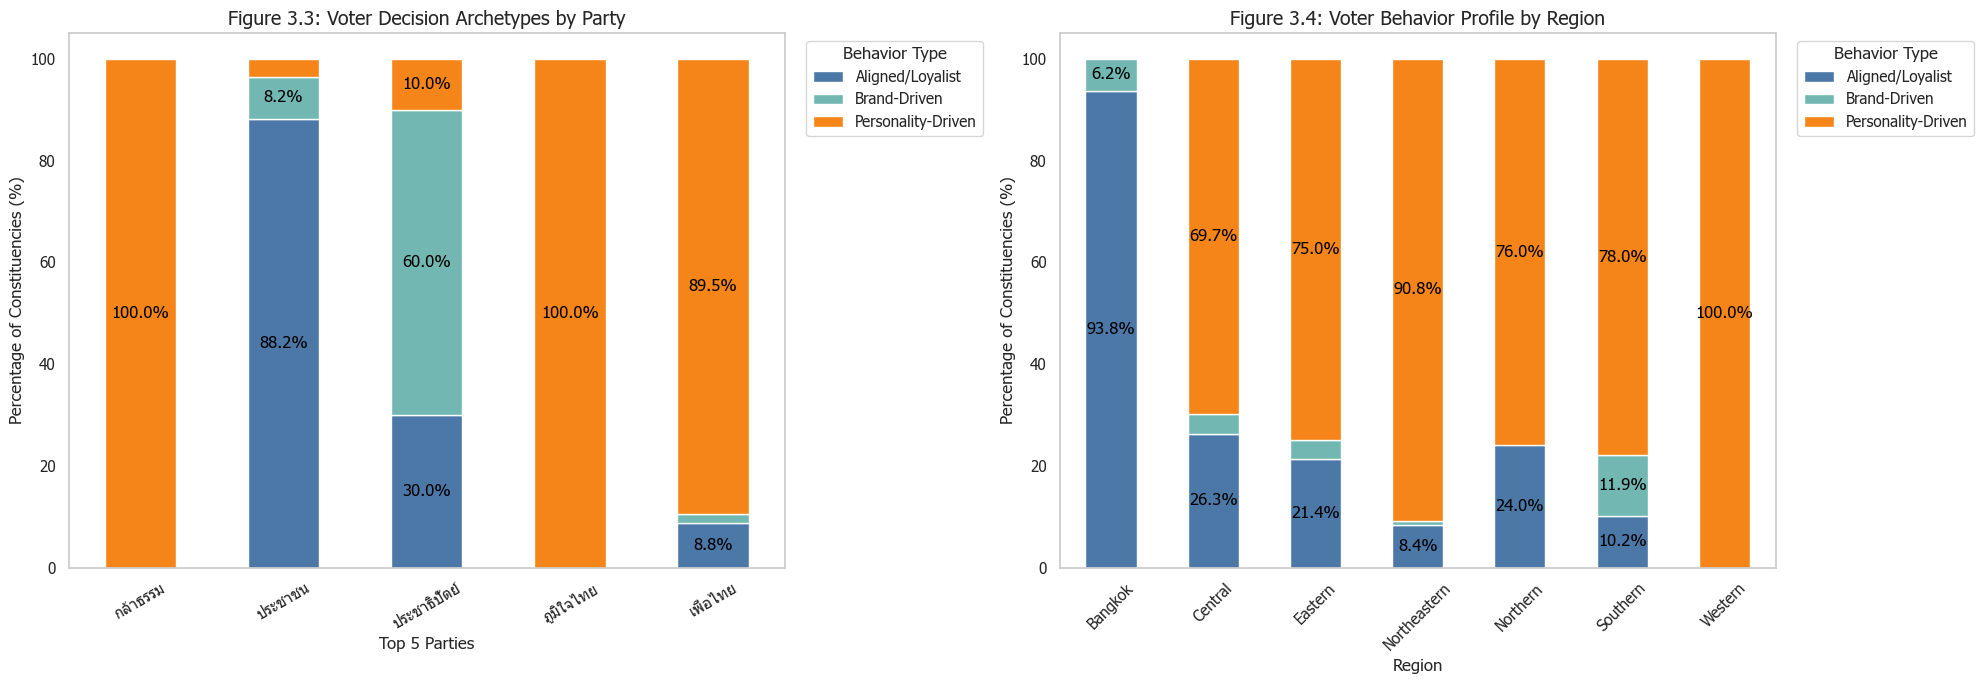

In [34]:
# Build behavior inputs for Figures 3.3 and 3.4.
winner_split_df = winner_split_df.merge(df_stats_cons_summary[['cons_id', 'party_list_valid_votes', 'prov_id']], on='cons_id', how='left')
winner_split_df['party_list_vote_percent'] = (winner_split_df['party_list_vote'] / winner_split_df['party_list_valid_votes'] * 100).fillna(0)

winner_split_df['tactical_gap'] = winner_split_df['mp_app_vote_percent'] - winner_split_df['party_list_vote_percent']

winner_split_df = winner_split_df.merge(df_prov_full[['prov_id', 'region']], on='prov_id', how='left')

def categorize_behavior(gap):
    if gap > 5: return 'Personality-Driven (Strong Candidate)'
    elif gap < -5: return 'Brand-Driven (Weak Candidate)'
    else: return 'Loyalist (Consistent Voting)'

winner_split_df['behavior_type'] = winner_split_df['tactical_gap'].apply(categorize_behavior)


def get_behavior_type(row):
    gap = row['mp_app_vote_percent'] - row['party_list_vote_percent']
    if gap > 5:
        return 'Personality-Driven'
    elif gap < -5:
        return 'Brand-Driven'
    else:
        return 'Aligned/Loyalist'

behavior_df = winner_split_df.dropna(subset=['region']).copy()
behavior_df['behavior_type'] = behavior_df.apply(get_behavior_type, axis=1)
top_5_parties = behavior_df['party_name'].value_counts().head(5).index
party_behavior_df = behavior_df[behavior_df['party_name'].isin(top_5_parties)].copy()
party_breakdown = party_behavior_df.groupby(['party_name', 'behavior_type']).size().unstack(fill_value=0)
party_breakdown_pct = party_breakdown.div(party_breakdown.sum(axis=1), axis=0) * 100
regional_breakdown = behavior_df.groupby(['region', 'behavior_type']).size().unstack(fill_value=0)
regional_breakdown_pct = regional_breakdown.div(regional_breakdown.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

party_breakdown_pct.plot(kind='bar', stacked=True, color=BEHAVIOR_COLORS, ax=axes[0])
axes[0].set_title('Figure 3.3: Voter Decision Archetypes by Party', fontsize=14)
axes[0].set_xlabel('Top 5 Parties')
axes[0].set_ylabel('Percentage of Constituencies (%)')
axes[0].legend(title='Behavior Type', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(False)
for bar_idx, (_, row) in enumerate(party_breakdown_pct.iterrows()):
    cumulative = 0
    for col in party_breakdown_pct.columns:
        val = row[col]
        if val >= 5:
            axes[0].text(bar_idx, cumulative + val / 2, f'{val:.1f}%',
                         ha='center', va='center', fontsize=12, color='black')
        cumulative += val

regional_breakdown_pct.plot(kind='bar', stacked=True, color=BEHAVIOR_COLORS, ax=axes[1])
axes[1].set_title('Figure 3.4: Voter Behavior Profile by Region', fontsize=14)
axes[1].set_ylabel('Percentage of Constituencies (%)')
axes[1].set_xlabel('Region')
axes[1].legend(title='Behavior Type', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(False)
for bar_idx, (_, row) in enumerate(regional_breakdown_pct.iterrows()):
    cumulative = 0
    for col in regional_breakdown_pct.columns:
        val = row[col]
        if val >= 5:
            axes[1].text(bar_idx, cumulative + val / 2, f'{val:.1f}%',
                         ha='center', va='center', fontsize=12, color='black')
        cumulative += val

plt.tight_layout()

plt.show()

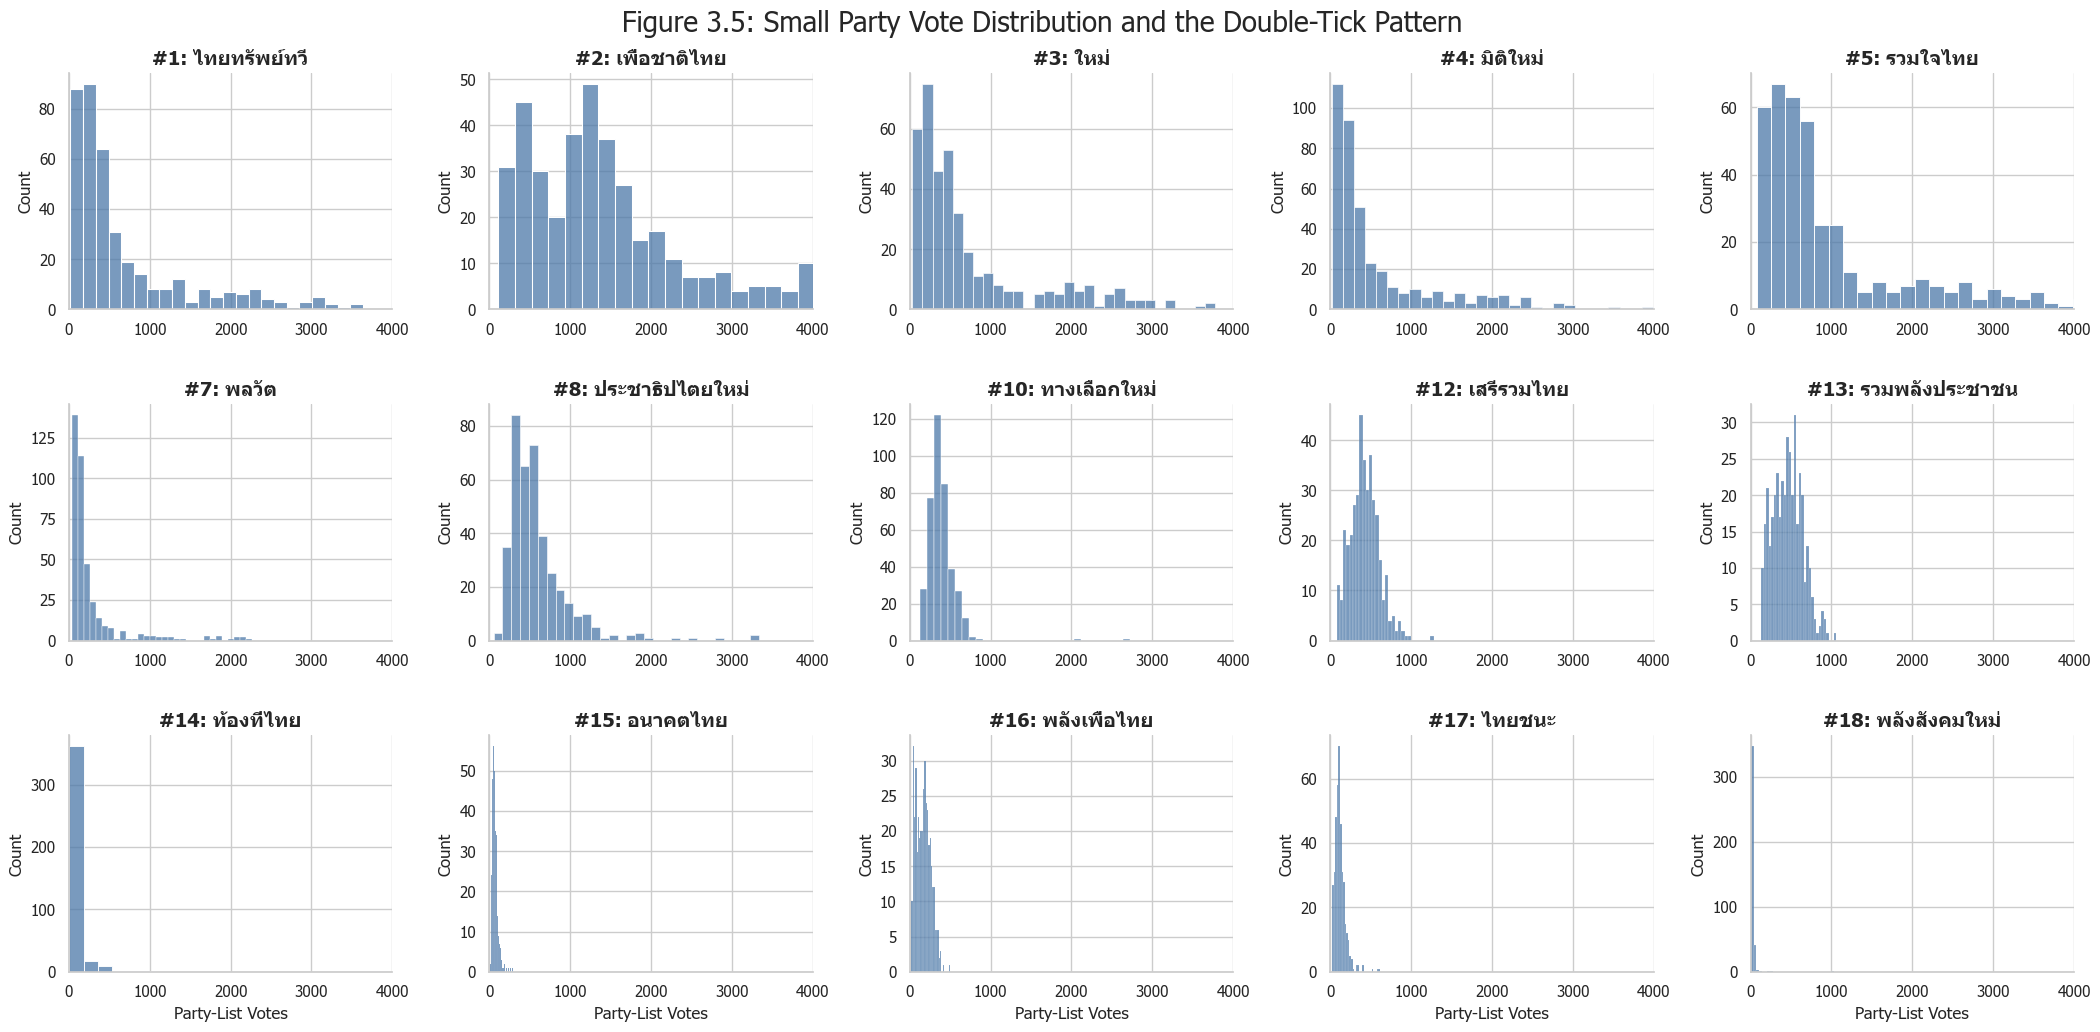

In [35]:

top_6_ids = df_stats_cons_party.groupby('party_id')['party_list_vote'].sum().nlargest(6).index.tolist()

df_party_info['party_no_num'] = pd.to_numeric(df_party_info['party_no'], errors='coerce')
target_parties = df_party_info[
    (df_party_info['party_no_num'].isin(range(1, 19))) & 
    (~df_party_info['id'].isin(top_6_ids))
][['id', 'party_no_num', 'name']]

votes_1_20 = df_stats_cons_party.merge(target_parties, left_on='party_id', right_on='id')

# Keep common x-scale across facets.
g = sns.FacetGrid(votes_1_20, col="name", col_wrap=5, sharex=True, sharey=False, height=3.5, aspect=1.2)
g.map(sns.histplot, "party_list_vote", bins=30, color=NONPARTY_SINGLE, alpha=0.75)

for ax in g.axes.flat:
    title_text = ax.get_title().split('= ')[-1]
    p_no = target_parties[target_parties['name'] == title_text]['party_no_num'].values[0]
    
    ax.set_title(f"#{int(p_no)}: {title_text}", fontsize=14, fontweight='bold')
    
    ax.set_xlabel('Party-List Votes', fontsize=12, labelpad=5)
    ax.tick_params(labelbottom=True)
    
    ax.set_xlim(0, 4000) 

plt.subplots_adjust(top=0.92, hspace=0.4, wspace=0.3)
g.fig.suptitle('Figure 3.5: Small Party Vote Distribution and the Double-Tick Pattern', fontsize=20)

plt.show()

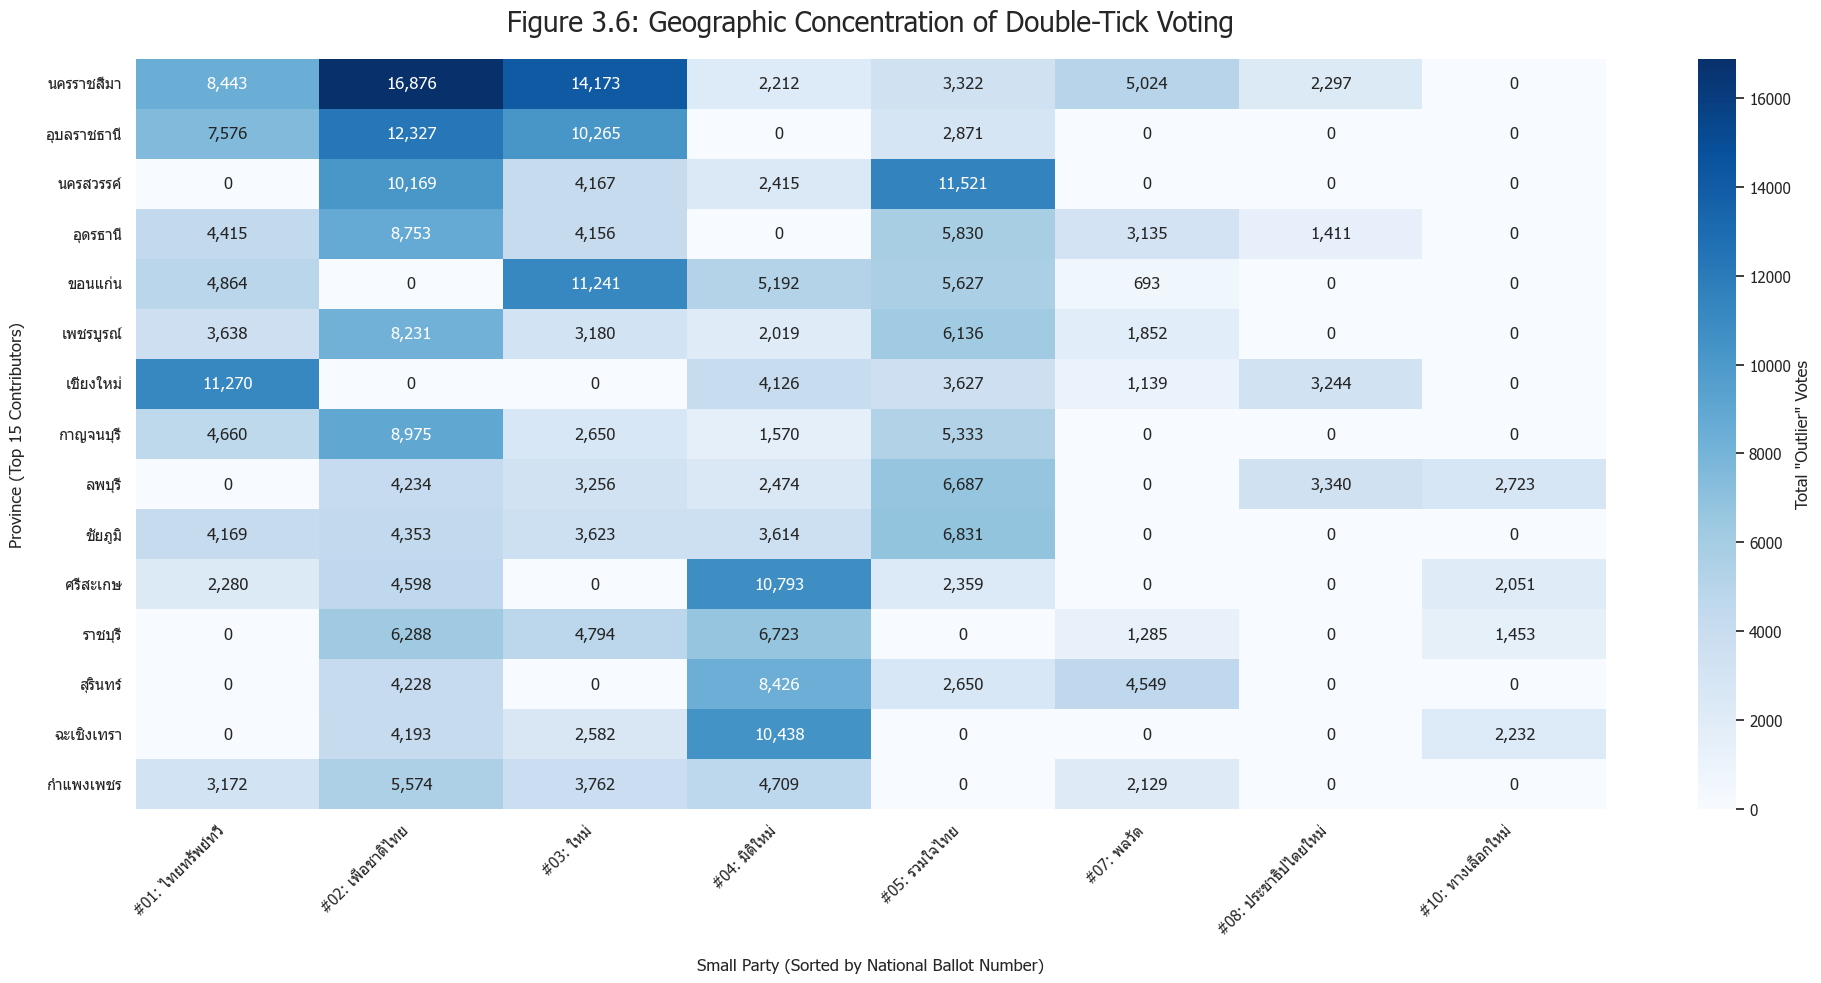

In [36]:
# Figure 3.6 prep.
top_6_ids = df_stats_cons_party.groupby('party_id')['party_list_vote'].sum().nlargest(6).index.tolist()
df_party_info['party_no_num'] = pd.to_numeric(df_party_info['party_no'], errors='coerce')

target_small_parties = df_party_info[
    (df_party_info['party_no_num'].isin(range(1, 11))) & 
    (~df_party_info['id'].isin(top_6_ids))
][['id', 'party_no_num', 'name']]

votes_small = df_stats_cons_party.merge(target_small_parties, left_on='party_id', right_on='id')

q_stats = votes_small.groupby('name')['party_list_vote'].agg([
    lambda x: x.quantile(0.25), 
    lambda x: x.quantile(0.75)
]).rename(columns={'<lambda_0>': 'Q1', '<lambda_1>': 'Q3'})
q_stats['IQR'] = q_stats['Q3'] - q_stats['Q1']
q_stats['Upper_Fence'] = q_stats['Q3'] + (1.5 * q_stats['IQR'])

votes_small = votes_small.merge(q_stats[['Upper_Fence']], left_on='name', right_index=True)
spikes_only = votes_small[votes_small['party_list_vote'] > votes_small['Upper_Fence']].copy()

spikes_with_prov = spikes_only.merge(df_constituencies[['cons_id', 'prov_id']], on='cons_id')

# Use Thai province names on y-axis
prov_name_col = 'province' if 'province' in df_prov_full.columns else next((c for c in ['province_name_en', 'prov_name_en', 'name_en'] if c in df_prov_full.columns), df_prov_full.columns[1])
final_spikes = spikes_with_prov.merge(df_prov_full[['prov_id', prov_name_col]], on='prov_id')

final_spikes['party_label'] = (
    "#" + final_spikes['party_no_num'].astype(int).map('{:02d}'.format) + 
    ": " + final_spikes['name']
)

prov_matrix = final_spikes.groupby([prov_name_col, 'party_label'])['party_list_vote'].sum().unstack(fill_value=0)

prov_matrix = prov_matrix.reindex(sorted(prov_matrix.columns), axis=1)
top_15_provs = prov_matrix.sum(axis=1).nlargest(15).index
final_heatmap_data = prov_matrix.loc[top_15_provs]

plt.figure(figsize=(20, 10))
sns.heatmap(final_heatmap_data, annot=True, fmt=',.0f', cmap=HEATMAP_CMAP, cbar_kws={'label': 'Total "Outlier" Votes'})

plt.title('Figure 3.6: Geographic Concentration of Double-Tick Voting', fontsize=20, pad=20)
plt.xlabel('Small Party (Sorted by National Ballot Number)', fontsize=12, labelpad=15)
plt.ylabel('Province (Top 15 Contributors)', fontsize=12, labelpad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

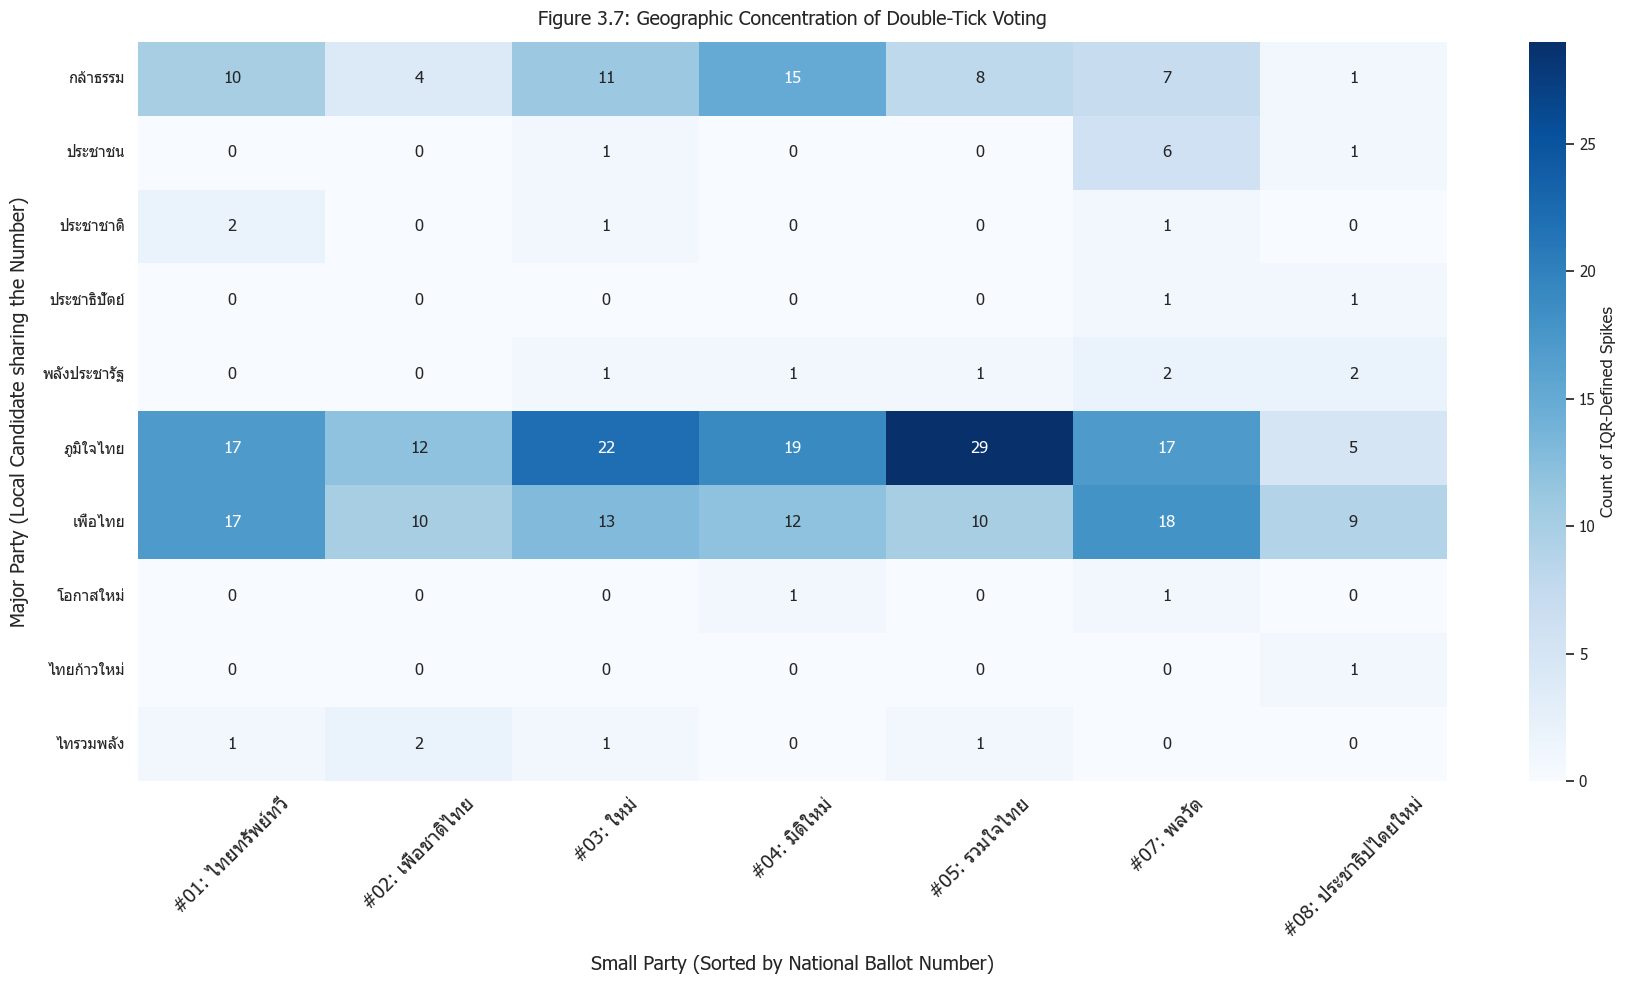

In [37]:
# Shared prep
top_6_ids = df_stats_cons_party.groupby('party_id')['party_list_vote'].sum().nlargest(6).index.tolist()

df_party_info['party_no_num'] = pd.to_numeric(df_party_info['party_no'], errors='coerce')
small_parties_df = df_party_info[
    (df_party_info['party_no_num'].isin(range(1, 21))) & 
    (~df_party_info['id'].isin(top_6_ids))
][['id', 'party_no_num', 'name']]

votes_1_20 = df_stats_cons_party.merge(small_parties_df, left_on='party_id', right_on='id')

q_stats = votes_1_20.groupby('name')['party_list_vote'].agg([
    lambda x: x.quantile(0.25), 
    lambda x: x.quantile(0.75)
]).rename(columns={'<lambda_0>': 'Q1', '<lambda_1>': 'Q3'})

q_stats['IQR'] = q_stats['Q3'] - q_stats['Q1']
q_stats['Upper_Fence'] = q_stats['Q3'] + (1.5 * q_stats['IQR'])

votes_1_20 = votes_1_20.merge(q_stats[['Upper_Fence']], left_on='name', right_index=True)
iqr_spikes_df = votes_1_20[votes_1_20['party_list_vote'] > votes_1_20['Upper_Fence']].copy()

df_cand_temp = df_stats_cons_cand.copy()
df_cand_temp['local_no'] = df_cand_temp['mp_app_id'].str.split('_').str[-1].astype(int)

benefactor_map = iqr_spikes_df.merge(
    df_cand_temp, 
    left_on=['cons_id', 'party_no_num'], 
    right_on=['cons_id', 'local_no']
)

benefactor_map = benefactor_map.merge(
    df_party_info[['id', 'name']], 
    left_on='party_id_y', right_on='id', 
    suffixes=('_small', '_big')
)

benefactor_map['small_party_label'] = (
    "#" + benefactor_map['party_no_num'].astype(int).map('{:02d}'.format) + 
    ": " + benefactor_map['name_small']
)

summary_iqr = benefactor_map.groupby(['name_big', 'small_party_label']).size().unstack(fill_value=0)
summary_iqr = summary_iqr.reindex(sorted(summary_iqr.columns), axis=1)

exclude_prefixes = ['#10:', '#14:', '#15:']
summary_iqr = summary_iqr[[c for c in summary_iqr.columns if not any(c.startswith(p) for p in exclude_prefixes)]]

# Plot Figure 3.7
fig37, ax37 = plt.subplots(figsize=(18, 10))

sns.heatmap(summary_iqr, annot=True, fmt='d', cmap=HEATMAP_CMAP, cbar_kws={'label': 'Count of IQR-Defined Spikes'}, ax=ax37)
ax37.set_title('Figure 3.7: Geographic Concentration of Double-Tick Voting', fontsize=14, pad=12)
ax37.set_xlabel('Small Party (Sorted by National Ballot Number)', fontsize=14, labelpad=10)
ax37.set_ylabel('Major Party (Local Candidate sharing the Number)', fontsize=14, labelpad=10)
ax37.tick_params(axis='x', rotation=45, labelsize=14)

plt.tight_layout()

plt.show()

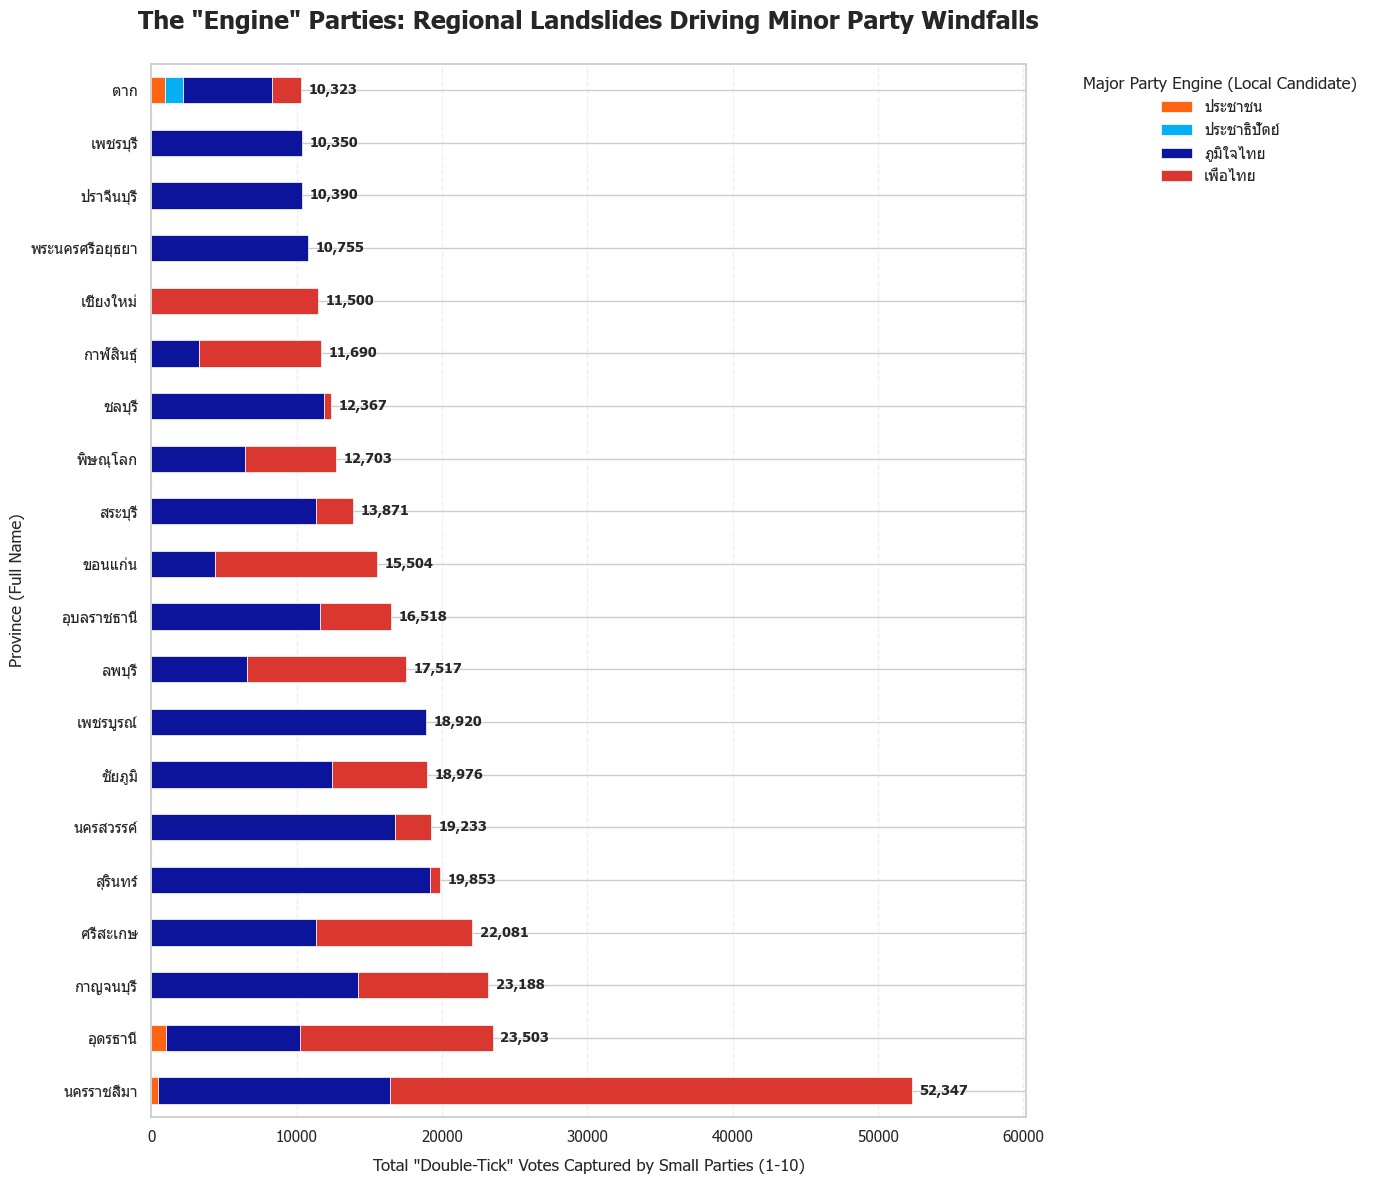

In [38]:
# Plot Figure 3.8
small_parties_1_10 = df_party_info[
    (df_party_info['party_no_num'].isin(range(1, 11))) & 
    (~df_party_info['id'].isin(top_6_ids))
][['id', 'party_no_num', 'name']]

votes_small = df_stats_cons_party.merge(small_parties_1_10, left_on='party_id', right_on='id')
q_stats_small = votes_small.groupby('name')['party_list_vote'].agg([
    lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)
]).rename(columns={'<lambda_0>': 'Q1', '<lambda_1>': 'Q3'})
q_stats_small['Upper_Fence'] = q_stats_small['Q3'] + (1.5 * (q_stats_small['Q3'] - q_stats_small['Q1']))
votes_small = votes_small.merge(q_stats_small[['Upper_Fence']], left_on='name', right_index=True)
spikes = votes_small[votes_small['party_list_vote'] > votes_small['Upper_Fence']].copy()

spikes_with_prov = spikes.merge(df_constituencies[['cons_id', 'prov_id']], on='cons_id')
df_cand_big = df_stats_cons_cand[df_stats_cons_cand['party_id'].isin(top_6_ids)].copy()
df_cand_big['number'] = df_cand_big['mp_app_id'].str.split('_').str[-1].astype(int)
benefactor_data = spikes_with_prov.merge(
    df_cand_big[['cons_id', 'number', 'party_id']],
    left_on=['cons_id', 'party_no_num'],
    right_on=['cons_id', 'number']
)
final_data = benefactor_data.merge(df_prov_full[['prov_id', 'province']], on='prov_id')
final_data = final_data.merge(df_party_info[['id', 'name']], left_on='party_id_y', right_on='id', suffixes=('_small', '_big'))

engine_summary = final_data.groupby(['province', 'name_big'])['party_list_vote'].sum().unstack(fill_value=0)

top_20_provinces = engine_summary.sum(axis=1).nlargest(20).index
plot_subset = engine_summary.loc[top_20_provinces]

current_engines = plot_subset.columns.tolist()
colors_to_use = [party_colors.get(name, '#D3D3D3') for name in current_engines]

ax = plot_subset.plot(kind='barh', stacked=True, figsize=(14, 12), color=colors_to_use, edgecolor='white', linewidth=0.5)

row_totals = plot_subset.sum(axis=1)
for i, (province, total) in enumerate(row_totals.items()):
    ax.text(total + row_totals.max() * 0.01, i, f'{total:,.0f}',
            va='center', ha='left', fontsize=10, fontweight='bold')

ax.set_xlim(0, row_totals.max() * 1.15)

plt.title('The "Engine" Parties: Regional Landslides Driving Minor Party Windfalls', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Total "Double-Tick" Votes Captured by Small Parties (1-10)', fontsize=12, labelpad=10)
plt.ylabel('Province (Full Name)', fontsize=12)
plt.legend(title='Major Party Engine (Local Candidate)', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()